In [1]:
using Printf
using LaTeXStrings
using CSV
using StatsKit
using Plots
using LsqFit
using Odrpack
using Optim
#using Images
#using Colors
#using FileIO

## Stabilità dell'intensità luminosa

In [ ]:
"""
Determina la deviazione standard del campione di misure di intensità luminosa.

# Argomenti:
- `intden_exp`: Il campione.
- `leg=(0.15, 0.95)`: Una tupla `(x,y)` per posizionare la legenda in modo che non dia fastidio.

# Ritorna:
- la deviazione standard del campione;
- il grafico con le misure e le tre deviazioni standard colorate.
"""
function analisi_incertezza_intensità(intden_exp; leg=(0.15, 0.95))
    # Determino la deviazione standard del campione
    mu = mean(intden_exp)
    sigma = std(intden_exp)
    
    # Plotto i valori di intensità con le barre di errore
    # e tre deviazioni standard attorno alla media
    p = plot()
    
    # Inizio dalle bande...
    colors = [:green, :yellow, :orange, :blue]
    αs = [0.25, 0.25, 0.15, 0.00]
    
    for (i, (c, α)) in zip(colors, αs) |> enumerate |> collect |> reverse
        lower = mu - i * sigma
        upper = mu + i * sigma
        
        label_text = i<4 ? "$(i)σ ≈ ±$(@sprintf("%0.1e", i*sigma))" : ""
        
        hline!(p, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
    end
    
    hline!(p, [mu], label="Intensità media", alpha=1)  # Linea sull'intensità media calcolata
    scatter!(p, intden_exp, yerr=sigma, label=("punti sperimentali"), legend=leg, xticks=1:length(intden_exp))  # Valori di intensità
    
    # Setto gli assi
    xlabel!(p, "# misura")
    ylabel!(p, "Intensità [u.a.]")

    return sigma, p
end

analisi_incertezza_intensità

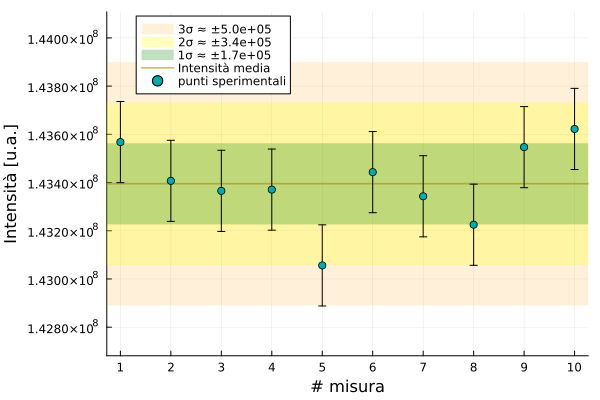

In [3]:
intensita_df = CSV.read("dati/intensita/intensita.csv", DataFrame)  # Leggo il `.csv` di ImageJ...
intden_exp = intensita_df.IntDen

intensita_std, p = analisi_incertezza_intensità(intden_exp)

savefig(p, "typst/grafici/intensita.svg")

plot(p)

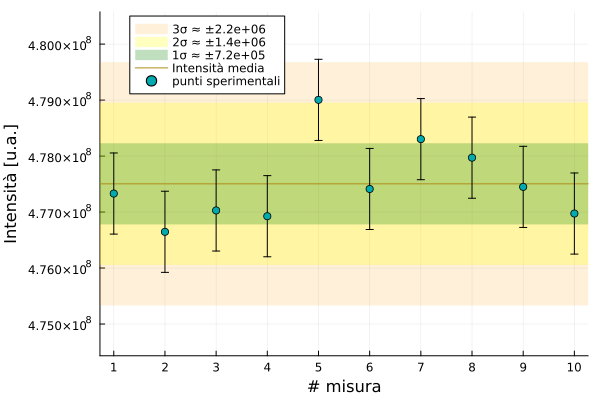

In [6]:
allineamento_esterno2_df = CSV.read("dati/allineamento/esterno2/allineamento_esterno2.csv", DataFrame)
intden_exp = allineamento_esterno2_df.IntDen

allineamento_esterno2_std, q = analisi_incertezza_intensità(intden_exp)

savefig(q, "typst/grafici/allineamento_esterno2.svg")

plot(q)

## Taratura del primo goniometro

In [16]:
# Il .csv ottenuto da ImageJ ha una colonna idiota che contiene
# il numero della misura. La sostituisco con una colonna "angolo".

angle = 120:10:220

calibrazione_p1_df = CSV.read("dati/calibrazione_p1/calibrazione_p1.csv", DataFrame)  # Leggo

DataFrames.rename!(calibrazione_p1_df, 1 => :Angle)  # Rinnomino
calibrazione_p1_df[!, 1] = angle  # Sostituisco

angle = calibrazione_p1_df.Angle
angle_rad = deg2rad.(angle)

x_angle = 115:0.1:225
x_angle_rad = deg2rad.(x_angle)

intden_exp = calibrazione_p1_df.IntDen

11-element Vector{Float64}:
 1.6408346e8
 1.99320277e8
 2.28650764e8
 2.50840336e8
 2.66381153e8
 2.76242978e8
 2.76765781e8
 2.70398811e8
 2.58071684e8
 2.36643589e8
 2.1088087e8

In [ ]:
"""
Plotta punti sperimentali, curva teorica di best fit e redisui di un fit fatto con LsqFit.

# Argomenti:
- `angle`: Vettore degli angoli.
- eccetera.

# Ritorna:
- Il plot.
"""
function plot_fit_lsq(angle, x_angle, intden_exp, x_intden_th, resid, sigma)
    # Plotto curva di best fit e punti sperimentali
    exp_th_plot = plot()
    plot!(exp_th_plot, x_angle, x_intden_th)  # La curva
    scatter!(exp_th_plot, angle, intden_exp, label="")  # I punti

    # Plotto i residui
    resid_plot = plot()
    scatter!(resid_plot, angle, resid, label="")  # I residui
    hline!(resid_plot, [0], c=:red, alpha=0.4, label="")  # Lo zero

    colors = [:green, :yellow, :orange]
    αs = [0.25, 0.25, 0.15]

    for (i, (c, α)) in zip(colors, αs) |> enumerate |> collect |> reverse
        lower = 0 - i * sigma
        upper = 0 + i * sigma

        label_text = "$(i)σ ≈ ±$(@sprintf("%0.1e", i*sigma))"

        hline!(resid_plot, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
    end

    exp_th_resid_plot = plot(
        exp_th_plot,
        resid_plot,
        link=:x,
        layout=(2,1),
        xlabel=["" "Angolo [°]"],
        ylabel=["Intensità [u.a.]" "Residui [u.a.]"],
        xticks=[(angle, []) (angle, angle)],
        legend=[(0.12, 0.9) (0.12,0.40)]
        )

    return exp_th_resid_plot
end

plot_fit_lsq (generic function with 2 methods)

In [18]:
# Faccio il fit pesato con LsqFit.jl senza incertezze sull'angolo
# usando l'incertezza sul valore di intensità 
# ricavata dalle misure che ho fatto io.

w = [1/(intensita_std^2)]

@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]  # Legge di Malus

p0 = [1e8, π, 0]

fit = curve_fit(model, angle_rad, intden_exp, w, p0)

# Qualità del fit
intden_th = model(angle_rad, fit.param)  # Perché fit.resid ritorna i residui PESATI
resid = intden_exp .- intden_th

@show chisq_min = sum(w .* resid.^2)
@show df = length(intden_exp) - length(fit.param)
@show pvalue = ccdf(Chisq(df), chisq_min)
@show pvalue = ccdf(TDist(df), chisq_min)
@show critico = quantile(Chisq(df), 1 - 0.05)

chisq_min = sum(w .* resid .^ 2) = 3934.0039991516983
df = length(intden_exp) - length(fit.param) = 8
pvalue = ccdf(Chisq(df), chisq_min) = 0.0
pvalue = ccdf(TDist(df), chisq_min) = 9.76132656510591e-27
critico = quantile(Chisq(df), 1 - 0.05) = 15.50731305586545


15.50731305586545

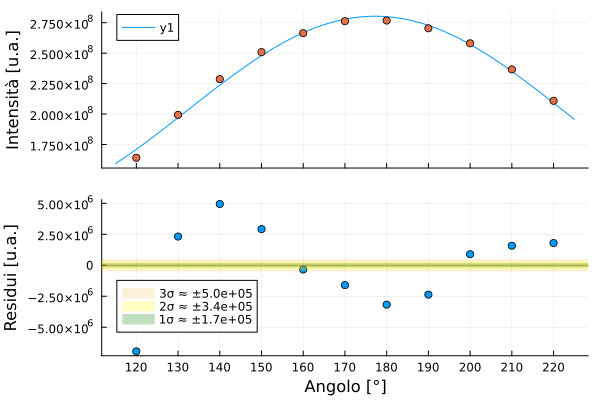

In [22]:
# Plotto

p = plot_fit_lsq(angle, x_angle, intden_exp, x_intden_th, resid, intensita_std)

plot(p)

In [23]:
# Trovo il massimo

f = x -> -model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(175)])

@show rad2deg.(Optim.minimizer(res))

rad2deg.(Optim.minimizer(res)) = [177.24321881096506]


1-element Vector{Float64}:
 177.24321881096506

In [37]:
function plot_chisq_mins(isigmas, dof, chisq_mins, pvalues)
    # # Determino i punti ottimi
    # j0 = argmin(abs.(chisq_mins .- 8))
    # @show isigma0 = isigmas[j0]
    # @show chisq_min0 = chisq_mins[j0]
    # @show pvalue0 = pvalues[j0]

    # j1 = argmin(abs.(chisq_mins .- 16))
    # @show isigma1 = isigmas[j1]
    # @show chisq_min1 = chisq_mins[j1]
    # @show pvalue1 = pvalues[j1]

    # Plotto i chisq_min
    chisq_mins_plot = plot()

    plot!(chisq_mins_plot, isigmas, chisq_mins, label="")  # incertezza vs. chi-quadro
    hline!(chisq_mins_plot, [dof], label="gradi di libertà: $(dof)", c=:red, alpha=0.4)  # Numero di gradi di libertà

    # Plotto i pvalue
    plvalues_plot = plot()

    plot!(plvalues_plot, isigmas, pvalues)

    # Metto tutto assieme
    p = plot(chisq_mins_plot, plvalues_plot, link=:x, layout=(2,1), xlabel=["" "s_I [u.a.]"], ylabel=["χ²_min" "p-dei-dati"])

    return p
end

plot_chisq_mins (generic function with 3 methods)

istd0 = istds[j0] = 3.73e6
chisq_min0 = chisq_mins[j0] = 8.005107366509668
pvalue0 = pvalues[j0] = 0.4329713747265324
istd1 = istds[j1] = 2.64e6
chisq_min1 = chisq_mins[j1] = 15.980007214117233
pvalue1 = pvalues[j1] = 0.04266716573974077


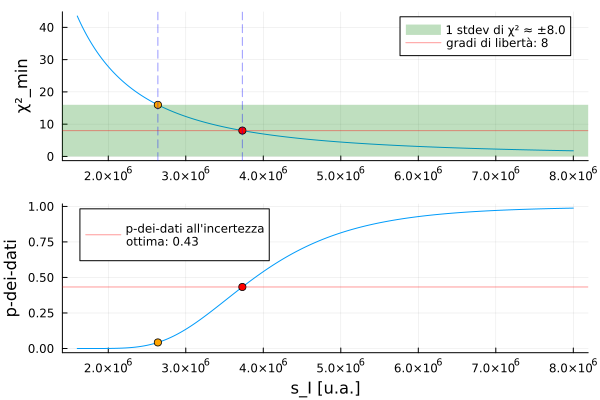

In [104]:
# Che incertezza avrei dovuto avere affinché il fit fosse buono?
# Plotto incertezze vs. chisq_min (o p-value) per scoprirlo.

# Faccio tutti i fit
istds = []
chisq_mins = []
pvalues = []

for istd in 1.6e6:10000:8e6
    push!(istds, istd)

    w = [1/(istd^2)]

    fit = curve_fit(model, deg2rad.(angle), intden_exp, w, p0)

    resid = intden_exp .- model(deg2rad.(angle), fit.param)
    chisq_min = sum(w .* resid.^2)
    pvalue = ccdf(Chisq(df), chisq_min)

    push!(chisq_mins, chisq_min)
    push!(pvalues, pvalue)
end


j0 = argmin(abs.(chisq_mins .- 8))  # Indice dove sta l'incertezza ottima
@show istd0 = istds[j0]  # Incertezza ottima
@show chisq_min0 = chisq_mins[j0]  #diocane
@show pvalue0 = pvalues[j0]

j1 = argmin(abs.(chisq_mins .- 16))  # Indice incertezza alla sigma del chi-quadro
@show istd1 = istds[j1]
@show chisq_min1 = chisq_mins[j1]
@show pvalue1 = pvalues[j1]


# Plotto chisq-min
p = plot()

plot!(p, istds, chisq_mins, label="")  # Curva chisq-min

for (i, (c, α)) in zip([colors[1]], [alphas[1]]) |> enumerate |> collect |> reverse
    lower = df - i * 2*sqrt(2*df)
    upper = df + i * 2*sqrt(2*df)

    label_text = i<4 ? "$(i) stdev di χ² ≈ ±$(i * 2*sqrt(2*df))" : ""

    hline!(p, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
end

scatter!(p, [istd0], [chisq_min0], label="", c=:red)  # Intersezione curva + df
scatter!(p, [istd1], [chisq_min1], label="", c=:orange)  # Intersezione curva + std del chi-qaudro

vline!(p, [istd0, istd1], label="", l=:dash, alpha=:0.4, c=:blue)

hline!(p, [8], label="gradi di libertà: 8", c=:red, alpha=0.4)#l=:dash)  #  Linea gradi di libertà
#hline!(p, [intensita_std], label="calcolata", c=:green, l=:dot)  # Incertezza calcolata

# Plotto p-value
q = plot()

plot!(q, istds, pvalues, label="")  # Curva p-value

scatter!(q, [istd0], [pvalue0], label="", c=:red)
scatter!(q, [istd1], [pvalue1], label="", c=:orange)

hline!(q, [pvalue0], label="p-dei-dati all'incertezza\nottima: $(round(pvalue0, digits=2))", c=:red, alpha=0.4)#l=:dash)

r = plot(p, q, link=:x, layout=(2,1), xlabel=["" "s_I [u.a.]"], ylabel=["χ²_min" "p-dei-dati"])

savefig(r, "typst/grafici/chisq_mins.svg")

plot(r)


In [19]:
# Faccio il fit pesato con ODRPACK con incertezze triangolari sull'angolo.
# Poi plotto dati sprimentali, fit e residui.

# Fit
function odr_model!(x, p, y)
    y .= p[1] .* cos.(x .+ p[2]).^2 .+ p[3]
    return nothing
end

sol = odr_fit(odr_model!, deg2rad.(angle), intden_exp, [1e8, 0, 0]; weight_x=1/(deg2rad(0.5)/sqrt(6))^2, weight_y=1/intensita_std^2)

# Qualità del fit
# intden_th = Vector{Float64}(undef, length(angle))
# odr_model!(deg2rad.(angle), sol.beta, intden_th)

# resid = intden_exp - intden_th

@show chisq_min = sol.sum_square  #sum(w .* resid.^2)
@show df = length(intden_exp) - length(fit.param)
@show pvalue = ccdf(Chisq(df), chisq_min)
@show pvalue = ccdf(TDist(df), chisq_min)
@show critico = quantile(Chisq(df), 1 - 0.05)

# Plotti
intden_th = Vector{Float64}(undef, length(x_angle))
odr_model!(deg2rad.(x_angle), sol.beta, intden_th)

p = plot()

scatter!(p, angle, intden_exp, label="exp", xticks=angle)
plot!(p, x_angle, intden_th, label="Malus (ODR)")
scatter!(p, angle, sol.yest, label="th (ODR)")


q = scatter(rad2deg.(sol.xplusd), -sol.eps, label="", xticks=round.(rad2deg.(sol.xplusd), digits=1))

for (i, (c, α)) in zip(colors, alphas) |> enumerate |> collect |> reverse
    lower = 0 - i * intensita_std
    upper = 0 + i * intensita_std

    label_text = i<4 ? "$(i)σ ≈ ±$(@sprintf("%0.1e", i*intensita_std))" : ""

    hline!(q, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
end

hline!(q, [0], c=:red, alpha=0.5, label="")

r = plot(p,
  q,
  layout=(2,1),
  link=:x,
  xlabel=["" "Angolo [°]"],
  ylabel=["Intensità [u.a.]" "Residui [u.a.]"],
  #xticks=[(angle, []) (angle, angle)],
  legend=[(0.12, 0.9) (0.80,0.35)]
)

savefig(r, "typst/grafici/calibrazione_p1_odr_residui.svg")

plot(r)

chisq_min = sol.sum_square = 555.2998549154713
df = length(intden_exp) - length(fit.param) = 8
pvalue = ccdf(Chisq(df), chisq_min) = 9.445196043663827e-115
pvalue = ccdf(TDist(df), chisq_min) = 6.19336941783557e-20
critico = quantile(Chisq(df), 1 - 0.05) = 15.50731305586545


UndefVarError: UndefVarError: `colors` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:
function chisq_min_odr(angle_deg, intden_exp, isigmas, m!)
    angle_deg = deg2rad.(angle)  # Converto l'angolo in radianti!

    chisq_mins = []
    pvalues_chi = []
    pvalues_t = []  # Non implementato

    for isigma in isigmas
        s_angle_rad = deg2rad(0.5)/sqrt(6)  # Incertezza su angolo in radianti
        weight_angle_rad = 1/s_angle_rad^2  # Peso su variabile angolo
        weight_intden_exp = 1/isigma^2  # Peso su variabile intensità
        
        p0 = [1e8, 0, 0]

        sol = odr_fit(m!, angle_deg, intden_exp, p0; weight_x=weight_angle_rad, weight_y=weight_intden_exp)
        
        dof = length(intden_exp) - length(sol.beta)  # Gradi di libertà
        
        chisq_min = sol.sum_square
        pvalue_chi = ccdf(Chisq(dof), chisq_min)
        pvalue_t = ccdf(TDist(dof), chisq_min)  # Non implementato

        push!(chisq_mins, chisq_min)
        push!(pvalues_chi, pvalue_chi)
        push!(pvalues_t, pvalue_t)  # Non implementato
    end

    return chisq_mins, pvalues_chi
end



chisq_min_odr (generic function with 4 methods)

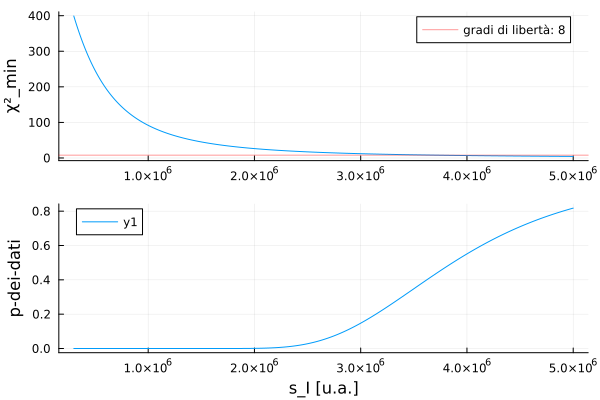

In [39]:
# Analisi dei chisq_mins con ODR

isigmas = 3e5:10000:5e6
chisq_mins, pvalues = chisq_min_odr(angle, intden_exp, isigmas, odr_model!)


p = plot_chisq_mins(isigmas, 8, chisq_mins, pvalues)

## Taratura del secondo goniometro

In [106]:
# index = 130:10:240

# calibrazione_p2_df = CSV.read("dati/calibrazione_p2/calibrazione_p2.csv", DataFrame)

# calibrazione_p2_df[!, 1] = index

# DataFrames.rename!(calibrazione_p2_df, 1 => :Angle)

# angle = calibrazione_p2_df.Angle
# x_angle = 125:0.1:245
# intden_exp = calibrazione_p2_df.IntDen


In [107]:
# # Plotto i punti sperimentali

# p = scatter(size=(800, 600), calibrazione_p2_df.Angle, calibrazione_p2_df.IntDen, label="punti sperimentali", xticks=calibrazione_p2_df.Angle, xrotation=45, xtickfontsize=6)
# xlabel!("Angolo [°]")
# ylabel!("Integral density [boh]")

In [108]:
# # Fitto i punti con Malus
# using LsqFit

# x_axis = range(120, 250, length=100)

# @. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

# p0 = [1e8, π, 0]

# fit = curve_fit(model, deg2rad.(calibrazione_p2_df.Angle), calibrazione_p2_df.IntDen, p0)

# # Trovo il massimo
# using Optim

# f = x -> -model(x[1], fit.param)[1]

# res = optimize(f, [deg2rad(180)])

# @show rad2deg.(Optim.minimizer(res)[1])


# # Plotto la curva a tre parametri fittata
# @show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Verifica della legge di Malus

In [109]:
# index = -30:15:195

# malus_df = CSV.read("malus/malus.csv", DataFrame)

# malus_df[!, 1] = index

# DataFrames.rename!(malus_df, 1 => :Angle)

In [110]:
# # Plotto i punti sperimentali

# p = scatter(size=(800, 600), malus_df.Angle, malus_df.IntDen, label="punti sperimentali", xticks=malus_df.Angle, xrotation=45, xtickfontsize=6)
# xlabel!("Angolo [°]")
# ylabel!("Integral density [boh]")

In [111]:
# # Fitto i punti con Malus
# using LsqFit

# x_axis = range(-40, 200, length=100)

# @. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

# p0 = [1e8, π, 0]

# fit = curve_fit(model, deg2rad.(malus_df.Angle), malus_df.IntDen, p0)

# # Trovo il minimo
# using Optim

# f = x -> model(x[1], fit.param)[1]

# res = optimize(f, [deg2rad(120)])

# @show rad2deg.(Optim.minimizer(res)[1])


# # Plotto la curva a tre parametri fittata
# @show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Lamina $ \lambda / 2 $

In [112]:
# index = 0:10:90

# lambdamezzi_df = CSV.read("lambdamezzi/lambdamezzi.csv", DataFrame)

# lambdamezzi_df[!, 1] = index

# DataFrames.rename!(lambdamezzi_df, 1 => :Angle)

In [113]:
# # Plotto i punti sperimentali

# p = scatter(size=(800, 600), lambdamezzi_df.Angle, lambdamezzi_df.IntDen, label="punti sperimentali", xticks=lambdamezzi_df.Angle, xrotation=45, xtickfontsize=6)
# xlabel!("Angolo [°]")
# ylabel!("Integral density [boh]")

In [114]:
# # Fitto i punti con Malus
# using LsqFit

# x_axis = range(-10, 100, length=100)

# @. model(x, p) = p[1] * cos(p[4]*x + p[2])^2 + p[3]

# p0 = [1e8, π/2, 0, 1]

# fit = curve_fit(model, deg2rad.(lambdamezzi_df.Angle), lambdamezzi_df.IntDen, p0)

# # Trovo il minimo
# using Optim

# f = x -> model(x[1], fit.param)[1]
# res = optimize(f, [deg2rad(70)])
# @show rad2deg.(Optim.minimizer(res)[1])

# g = x -> -model(x[1], fit.param)[1]
# res = optimize(g, [deg2rad(20)])
# @show rad2deg.(Optim.minimizer(res)[1])


# # Plotto la curva a tre parametri fittata
# @show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

In [115]:
# fit.param